# Indicador de estrés financiero

Este notebook construye un indicador de estrés financiero a partir de variables macroeconómicas y financieras. El flujo incluye carga y exploración de datos, análisis de relaciones entre variables, estimación de una regresión logística para aproximar la probabilidad de crisis y visualización de la serie estimada junto con su tendencia.

El archivo fue preparado para poder ejecutarse tanto en un entorno local como en Google Colab.

In [1]:
import pandas as pd
import statsmodels as stats
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LogisticRegression

try:
    from google.colab import files
    EN_COLAB = True
except ImportError:
    files = None
    EN_COLAB = False

## 1. Carga de datos

En esta sección se define el archivo de entrada y se carga la base de trabajo. Si el notebook se ejecuta en local, toma `Datos Modelo.xlsx` desde la carpeta del proyecto; en Colab, permite usar carga manual como respaldo.

In [2]:
DATA_FILE = Path("Datos Modelo.xlsx")

if DATA_FILE.exists():
    data_source = DATA_FILE
elif EN_COLAB:
    uploaded = files.upload()
    uploaded_name = next(iter(uploaded))
    data_source = Path(uploaded_name)
else:
    raise FileNotFoundError("No se encontro 'Datos Modelo.xlsx' en la carpeta de trabajo.")

print(f"Usando archivo: {data_source}")

Usando archivo: Datos Modelo.xlsx


In [3]:
Data = pd.read_excel(data_source)
Data = pd.DataFrame(Data)
Data.head()
Data.describe()

,Fecha,MTI,Crisis,i,M3,Incremento M3,EMAE,Incremento EMAE,DF,TCR,TCR-M,TCR-M-1,DCC,DCC-1,IPMP,Imp,Reservas,Incremento Reservas,Res/Imp,Deuda ext
count,234,234.000000,234.000000,234.000000,2.330000e+02,232.000000,233.000000,222.000000,234.000000,234.000000,2.340000e+02,222.000000,195.000000,189.000000,234.000000,234.000000,234.000000,222.000000,234.000000,210.000000
mean,2013-09-15 15:41:32.307692,0.507736,0.111111,22.673077,3.666965e+09,0.024919,136.602120,0.019740,-0.027299,121.619544,-1.943365e-15,1.566981,-0.008652,-0.008553,235.793852,4648.324786,38917.521368,0.099448,8.787325,194921.373448
min,2004-01-01 00:00:00,-4.919078,0.000000,1.125000,1.197259e+08,-0.067240,95.125392,-1.000000,-0.085900,74.049951,-4.756959e+01,-47.569593,-0.057658,-0.057658,132.260973,1364.000000,9326.000000,-0.392043,4.898084,130145.321159
25%,2008-11-08 12:00:00,-0.583151,0.000000,10.828125,3.013856e+08,0.010178,128.435940,-0.017713,-0.054400,98.261612,-2.335793e+01,-20.907103,-0.025244,-0.026855,198.704056,3536.750000,29022.750000,-0.078608,6.684564,153754.171744
50%,2013-09-16 00:00:00,0.242095,0.000000,19.187500,9.234179e+08,0.020005,143.473925,0.026717,-0.030200,117.649945,-3.969599e+00,-2.645684,-0.008685,-0.008440,217.021463,4767.000000,42556.500000,0.047499,7.600471,161281.066593
75%,2018-07-24 06:00:00,1.140265,0.000000,29.687500,3.844518e+09,0.033412,147.242539,0.073198,0.003500,148.574561,2.695502e+01,28.442337,0.009536,0.010026,290.798203,5736.000000,47521.250000,0.299411,9.247003,267537.066109
max,2023-06-01 00:00:00,11.234132,1.000000,92.250000,3.392502e+10,0.116347,152.552876,0.315511,0.039700,169.352896,4.773335e+01,47.733352,0.027376,0.027376,372.457338,8664.000000,71663.000000,0.782035,24.762612,283129.143831
std,NaN,1.998859,0.314943,17.174126,6.254803e+09,0.024237,14.581813,0.095709,0.033526,26.911602,2.691160e+01,26.741337,0.022042,0.022381,58.753666,1482.176571,13141.614776,0.262383,3.551216,54503.589702


## 2. Exploración inicial

Primero se revisan estadísticos descriptivos y luego se observan correlaciones y relaciones bivariadas entre variables relevantes para el indicador.

In [4]:
# Paso opcional: eliminar columnas si se quiere trabajar con una seleccion reducida.
# Data = Data.drop(['MTI', 'M3', 'EMAE', 'TCR', 'TCR-M', 'Imp', 'DCC', 'Reservas'], axis=1)

In [5]:
# Paso opcional: eliminar filas con valores faltantes antes de algunos gráficos o modelos.
# Data = Data.dropna()
Data.head()

,Fecha,MTI,Crisis,i,M3,Incremento M3,EMAE,Incremento EMAE,DF,TCR,TCR-M,TCR-M-1,DCC,DCC-1,IPMP,Imp,Reservas,Incremento Reservas,Res/Imp,Deuda ext
0,2004-01-01,0.000000,0,1.5000,119725909.0,NaN,98.237092,NaN,0.0397,159.536848,37.917304,NaN,NaN,NaN,161.449069,1609,9326,NaN,5.796147,NaN
1,2004-02-01,-1.759873,0,1.1250,120882595.0,0.009661,98.087555,NaN,0.0397,159.662715,38.043172,NaN,NaN,NaN,167.807290,1364,10289,NaN,7.543255,NaN
2,2004-03-01,2.797945,1,1.6875,120780924.0,-0.000841,97.663962,NaN,0.0397,155.118220,33.498676,NaN,NaN,NaN,183.684327,1690,10517,NaN,6.223077,NaN
3,2004-04-01,-0.409126,0,1.8125,123897338.0,0.025802,95.125392,NaN,0.0397,151.164852,29.545308,NaN,NaN,NaN,184.549316,1651,10971,NaN,6.645064,NaN
4,2004-05-01,7.099515,1,3.8750,128684876.0,0.038641,96.985385,NaN,0.0397,155.046584,33.427040,NaN,NaN,NaN,181.897997,1792,11374,NaN,6.347098,NaN


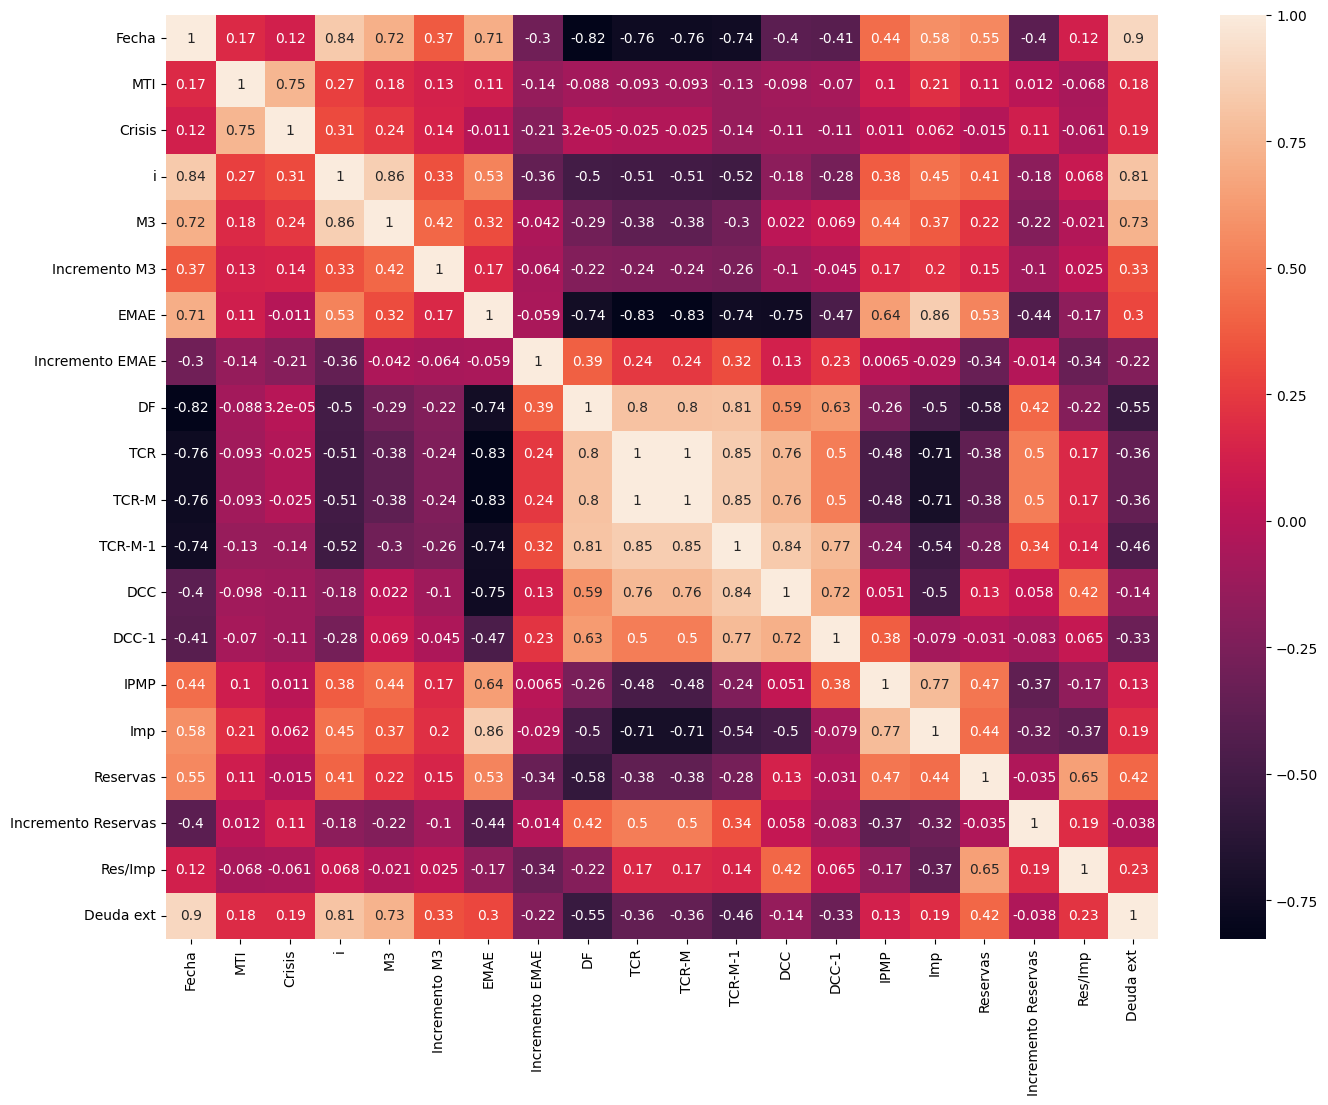

In [6]:
DataCorr = Data.corr(method='pearson')

plt.figure(figsize=(16, 12))
sns.heatmap(DataCorr, annot=True)
plt.show()

## Vemos que el hecho de tener 'Crisis' se relaciona linealmente sobre todo con subas de la tasa (i)
## y con el agregado M3 (igualmente para la regresión usamos su incremento)
## Por otra parte, el incremento del EMAE (Actividad Económica) se relaciona negativamente

<Axes: xlabel='MTI', ylabel='DF'>

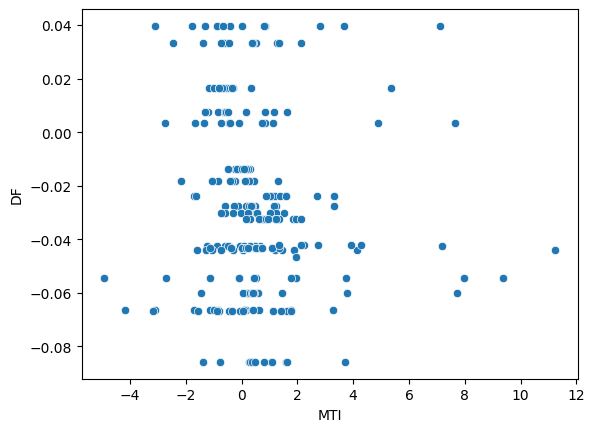

In [7]:
sns.scatterplot(x = "MTI",
                y = "DF", data = Data)

<Axes: xlabel='Crisis', ylabel='Incremento M3'>

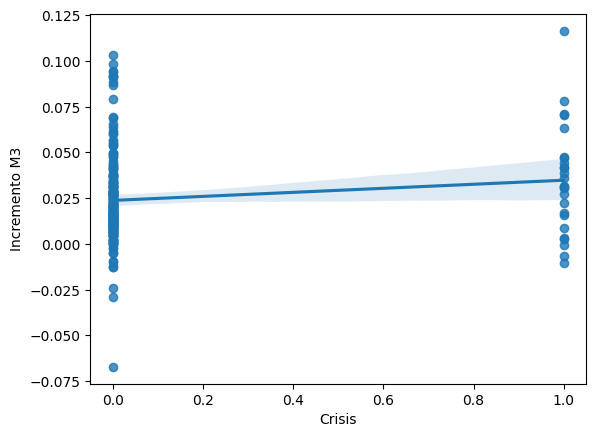

In [8]:
sns.regplot(x = "Crisis", y = "Incremento M3", data = Data)

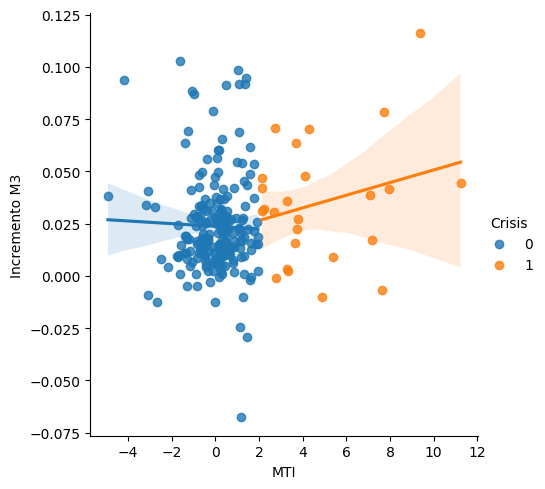

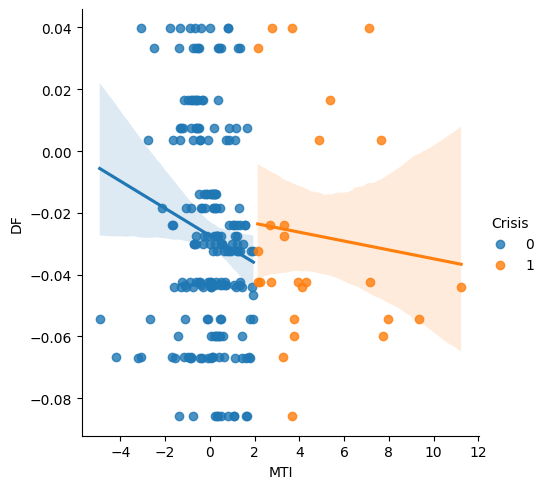

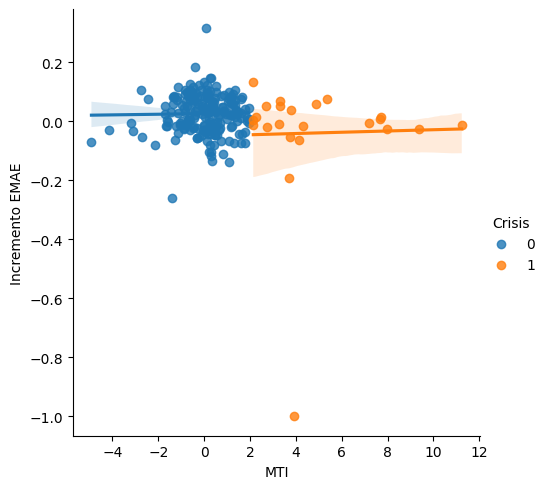

In [9]:
sns.lmplot(x = "MTI", y = "Incremento M3",
           hue = "Crisis", data = Data)
sns.lmplot(x = "MTI", y = "DF",
           hue = "Crisis", data = Data)
sns.lmplot(x = "MTI", y = "Incremento EMAE",
           hue = "Crisis", data = Data)

## 3. Modelo de probabilidad de crisis

Se estima una regresión logística para aproximar la probabilidad de un episodio de estrés o crisis en función de variables monetarias, cambiarias y de actividad.

In [10]:
# Especificación y estimación del modelo logit
VariablesModelo = [
    'Incremento M3', 'i', 'Incremento EMAE', 'DF', 'TCR-M-1',
    'DCC-1', 'IPMP', 'Incremento Reservas', 'Res/Imp', 'Deuda ext'
]

DataLogit = Data[['Fecha', 'Crisis'] + VariablesModelo].dropna().copy()
DataLogit['Fecha'] = pd.to_datetime(DataLogit['Fecha'])

Y = DataLogit['Crisis']
X = sm.add_constant(DataLogit[VariablesModelo], has_constant='add')

ModeloLogit = sm.Logit(Y, X)
ResultadosLogit = ModeloLogit.fit(disp=False, maxiter=200)

print(f'Observaciones utilizadas: {len(DataLogit)}')
print(f'Proporción de crisis en la muestra: {Y.mean():.2%}')
print(ResultadosLogit.summary())

Observaciones utilizadas: 188
Proporción de crisis en la muestra: 10.64%
                           Logit Regression Results                           
Dep. Variable:                 Crisis   No. Observations:                  188
Model:                          Logit   Df Residuals:                      177
Method:                           MLE   Df Model:                           10
Date:                Fri, 20 Mar 2026   Pseudo R-squ.:                  0.2849
Time:                        03:03:30   Log-Likelihood:                -45.562
converged:                       True   LL-Null:                       -63.710
Covariance Type:            nonrobust   LLR p-value:                 7.484e-05
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.2368      2.944     -0.080      0.936      -6.007       5.534
Incremento M3          12.3969 

In [11]:
# Diagnóstico básico de multicolinealidad
from statsmodels.stats.outliers_influence import variance_inflation_factor

VIF = pd.DataFrame({
    'Variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

VIF = VIF[VIF['Variable'] != 'const'].sort_values('VIF', ascending=False)
VIF

,Variable,VIF
10,Deuda ext,6.361546
4,DF,5.488557
5,TCR-M-1,5.344147
2,i,4.647341
6,DCC-1,3.593486
9,Res/Imp,2.898880
3,Incremento EMAE,2.551316
7,IPMP,2.098461
8,Incremento Reservas,1.796245
1,Incremento M3,1.213742


In [12]:
# Odds ratios y efectos marginales del modelo
OddsRatios = pd.DataFrame({
    'Variable': ResultadosLogit.params.index,
    'Odds ratio': np.exp(ResultadosLogit.params),
    'IC 2.5%': np.exp(ResultadosLogit.conf_int()[0]),
    'IC 97.5%': np.exp(ResultadosLogit.conf_int()[1]),
    'p-valor': ResultadosLogit.pvalues
}).round(3)

LogitMargEff = ResultadosLogit.get_margeff(at='mean')

print('Odds ratios del modelo:')
print(OddsRatios)
print('\nEfectos marginales en la media:')
print(LogitMargEff.summary())

Odds ratios del modelo:
                                Variable  Odds ratio  IC 2.5%      IC 97.5%  \
const                              const       0.789    0.002  2.530430e+02   
Incremento M3              Incremento M3  242057.090    0.001  8.433224e+13   
i                                      i       1.150    1.060  1.248000e+00   
Incremento EMAE          Incremento EMAE       0.014    0.000  1.204594e+06   
DF                                    DF       0.000    0.000  2.504069e+09   
TCR-M-1                          TCR-M-1       1.039    0.979  1.102000e+00   
DCC-1                              DCC-1       0.000    0.000  1.194877e+14   
IPMP                                IPMP       0.999    0.981  1.018000e+00   
Incremento Reservas  Incremento Reservas      45.413    2.416  8.536520e+02   
Res/Imp                          Res/Imp       0.902    0.661  1.230000e+00   
Deuda ext                      Deuda ext       1.000    1.000  1.000000e+00   

                     p-valo

## 4. Serie estimada y tendencia

A partir del modelo se calcula la probabilidad predicha y se visualiza su evolución temporal. Luego se aplica un suavizado exponencial simple para resumir la tendencia del indicador.

Accuracy con umbral 0.5: 90.43%
ROC AUC: 0.879
Matriz de confusión:
[[165   3]
 [ 15   5]]


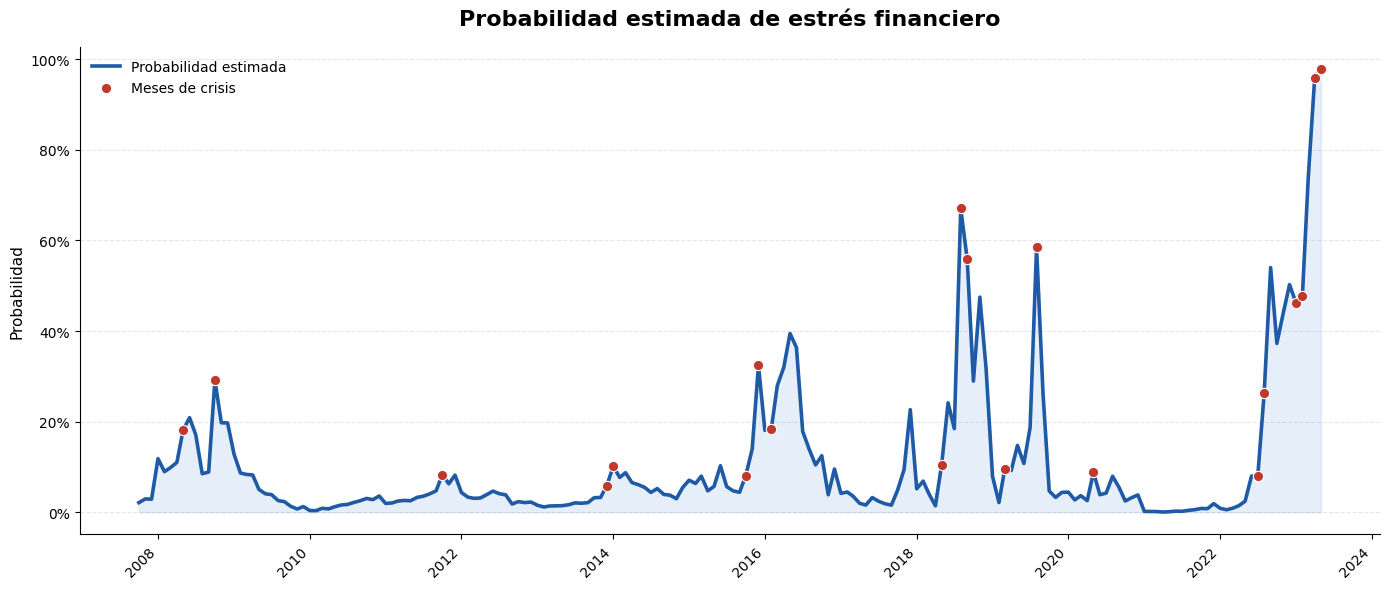

In [13]:
# Cálculo de la probabilidad predicha y preparación de la serie para graficar
from matplotlib.ticker import PercentFormatter

from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

Prediccion = ResultadosLogit.predict(X)
DataLogit = DataLogit.copy()
DataLogit['Prediccion'] = Prediccion
DataLogit['Prediccion_binaria'] = (DataLogit['Prediccion'] >= 0.5).astype(int)
DataLogit = DataLogit.sort_values('Fecha')

accuracy = accuracy_score(DataLogit['Crisis'], DataLogit['Prediccion_binaria'])
auc = roc_auc_score(DataLogit['Crisis'], DataLogit['Prediccion'])
matriz_confusion = confusion_matrix(DataLogit['Crisis'], DataLogit['Prediccion_binaria'])

print(f'Accuracy con umbral 0.5: {accuracy:.2%}')
print(f'ROC AUC: {auc:.3f}')
print('Matriz de confusión:')
print(matriz_confusion)

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(
    data=DataLogit,
    x='Fecha',
    y='Prediccion',
    ax=ax,
    color='#1f5aa6',
    linewidth=2.6,
    label='Probabilidad estimada'
)
ax.fill_between(DataLogit['Fecha'], DataLogit['Prediccion'], color='#8fb7e8', alpha=0.22)

crisis = DataLogit[DataLogit['Crisis'] == 1]
ax.scatter(
    crisis['Fecha'],
    crisis['Prediccion'],
    color='#c0392b',
    edgecolor='white',
    linewidth=0.8,
    s=55,
    zorder=5,
    label='Meses de crisis'
)

ax.set_title('Probabilidad estimada de estrés financiero', fontsize=16, fontweight='bold', pad=16)
ax.set_xlabel('')
ax.set_ylabel('Probabilidad', fontsize=11)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(True, axis='y', linestyle='--', alpha=0.30)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

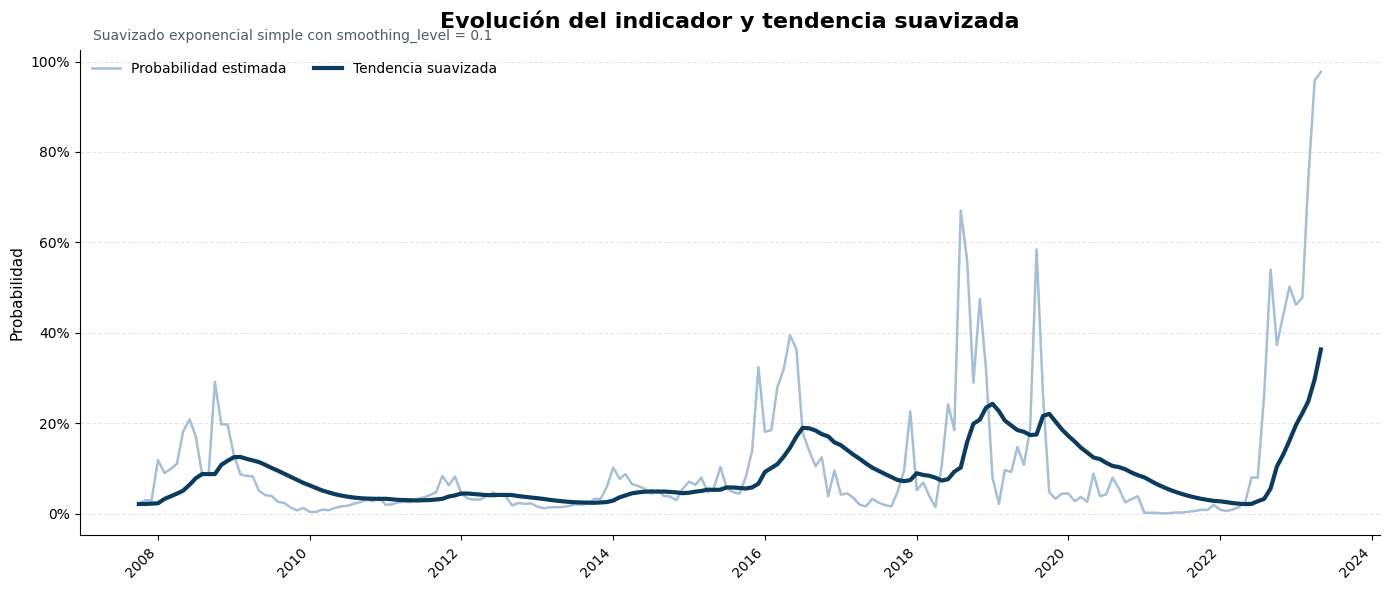

In [14]:
from statsmodels.tsa.api import SimpleExpSmoothing

Tendencia = SimpleExpSmoothing(DataLogit['Prediccion']).fit(smoothing_level=0.1, optimized=False)
DataLogit['Tendencia'] = Tendencia.fittedvalues

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(
    data=DataLogit,
    x='Fecha',
    y='Prediccion',
    ax=ax,
    color='#9bb8d3',
    linewidth=1.8,
    alpha=0.9,
    label='Probabilidad estimada'
)
sns.lineplot(
    data=DataLogit,
    x='Fecha',
    y='Tendencia',
    ax=ax,
    color='#0b3c5d',
    linewidth=3,
    label='Tendencia suavizada'
)

ax.set_title('Evolución del indicador y tendencia suavizada', fontsize=16, fontweight='bold', pad=16)
ax.text(
    0.01,
    1.02,
    'Suavizado exponencial simple con smoothing_level = 0.1',
    transform=ax.transAxes,
    fontsize=10,
    color='#4f5b66'
)
ax.set_xlabel('')
ax.set_ylabel('Probabilidad', fontsize=11)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(True, axis='y', linestyle='--', alpha=0.30)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, loc='upper left', ncol=2)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [15]:
## Para guardar o descargar
output_file = Path('DatosLogit.xlsx')
DataLogit.to_excel(output_file, index=False)
print(f"Archivo guardado en: {output_file.resolve()}")

if EN_COLAB:
    files.download(str(output_file))

Archivo guardado en: C:\Archivos compartidos\Portafolio\Python\Indicador estres financiero\DatosLogit.xlsx


## Extensión posible

Como trabajo futuro, este análisis puede ampliarse con modelos alternativos de clasificación, por ejemplo Naive Bayes u otros algoritmos supervisados, para comparar desempeño y robustez frente a la regresión logística.